# Part 2: Building Footprint Segmentation

UNLV technical assessment (Dr. Sohn's lab). Design decisions are recorded in `PART2_PLAN.md`.

**Sections**
0. Setup and reproducibility
1. Data loading and verification
2. Patch extraction and leakage-safe partitioning
3. *(next)* Model, loss, and training setup
4. *(next)* Training runs (primary split, then leave-one-city-out)
5. *(next)* Quantitative evaluation
6. *(next)* Qualitative visual analysis

## 0. Setup and reproducibility

In [1]:
import os, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tifffile
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = Path("../datasets/aerial_imagery")  # notebook moved into code/; data lives at project_root/datasets/

plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "font.size": 9})

print(f"torch={torch.__version__}  smp={smp.__version__}  albumentations={A.__version__}  cv2={cv2.__version__}")
print(f"device={DEVICE}", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

torch=2.14.0+cu126  smp=0.5.0  albumentations=2.0.8  cv2=5.0.0
device=cuda NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Data loading and verification

The dataset is already extracted locally (`PART2_PLAN.md` Section 2). Train tiles have masks; test tiles do not
(confirmed against the official project page), so **we split the 180 labeled train tiles ourselves**
(`PART2_PLAN.md` Section 4) rather than using the provided train/test folders directly.

In [2]:
TRAIN_CITIES = ["austin", "chicago", "kitsap", "tyrol-w", "vienna"]
IMG_DIR = DATA_ROOT / "train" / "images"
GT_DIR = DATA_ROOT / "train" / "gt"

all_tiles = sorted(IMG_DIR.glob("*.tif"))
counts = pd.Series([f.stem.rstrip("0123456789") for f in all_tiles]).value_counts()
print("Tiles per city (full labeled set):")
print(counts.reindex(TRAIN_CITIES))
assert (counts.reindex(TRAIN_CITIES) == 36).all(), "expected 36 tiles per city"
assert len(all_tiles) == 180

# scope decision (PART2_PLAN.md Section 3): 8 tiles per city, fixed indices 1-8, for reproducibility
SUBSET_IDS = list(range(1, 9))
SELECTED_TILES = [(city, tid) for city in TRAIN_CITIES for tid in SUBSET_IDS]
print(f"\nUsing {len(SELECTED_TILES)} of {len(all_tiles)} labeled tiles "
      f"({len(SUBSET_IDS)} per city x {len(TRAIN_CITIES)} cities).")

Tiles per city (full labeled set):
austin     36
chicago    36
kitsap     36
tyrol-w    36
vienna     36
Name: count, dtype: int64

Using 40 of 180 labeled tiles (8 per city x 5 cities).


In [3]:
# spec verification on one sample tile (must match the assessment brief exactly)
sample_img = tifffile.imread(IMG_DIR / "austin1.tif")
sample_mask = tifffile.imread(GT_DIR / "austin1.tif")
print(f"image: shape={sample_img.shape} dtype={sample_img.dtype} range=[{sample_img.min()},{sample_img.max()}]")
print(f"mask:  shape={sample_mask.shape} dtype={sample_mask.dtype} unique values={np.unique(sample_mask)}")
assert sample_img.shape == (5000, 5000, 3) and sample_img.dtype == np.uint8
assert sample_mask.shape == (5000, 5000) and set(np.unique(sample_mask).tolist()) <= {0, 255}

image: shape=(5000, 5000, 3) dtype=uint8 range=[0,255]
mask:  shape=(5000, 5000) dtype=uint8 unique values=[  0 255]


In [4]:
# preload the 40 selected tiles into memory once (image ~75MB + mask ~25MB per tile => ~4GB total, fits in 31GB RAM)
# -- avoids re-reading each 5000x5000 tif from disk for every one of its 81 patches.
t0 = time.time()
TILES = {}
for city, tid in SELECTED_TILES:
    name = f"{city}{tid}"
    img = tifffile.imread(IMG_DIR / f"{name}.tif")
    mask = (tifffile.imread(GT_DIR / f"{name}.tif") == 255).astype(np.uint8)
    TILES[(city, tid)] = {"img": img, "mask": mask}
print(f"Preloaded {len(TILES)} tiles in {time.time()-t0:.1f}s "
      f"({sum(v['img'].nbytes + v['mask'].nbytes for v in TILES.values())/1e9:.2f} GB in RAM)")

Preloaded 40 tiles in 2.4s (4.00 GB in RAM)


### Class imbalance and per-city heterogeneity

The assessment explicitly warns that pixel accuracy is misleading here. We quantify exactly how imbalanced (and
how *heterogeneous across cities*) the building/background split is, over the full 40-tile subset.

          mean    min    max
city                        
austin   13.6%   8.1%  18.7%
chicago  22.1%  14.4%  31.1%
kitsap    1.8%   0.2%   5.8%
tyrol-w   6.4%   4.2%  10.4%
vienna   28.1%  11.2%  46.4%

Overall mean building coverage: 14.4% (range 0.2%-46.4%)
A trivial all-background classifier would score >85% pixel accuracy on average, and >99% on the sparsest (Kitsap) tiles -- pixel accuracy alone would be a badly misleading metric here.


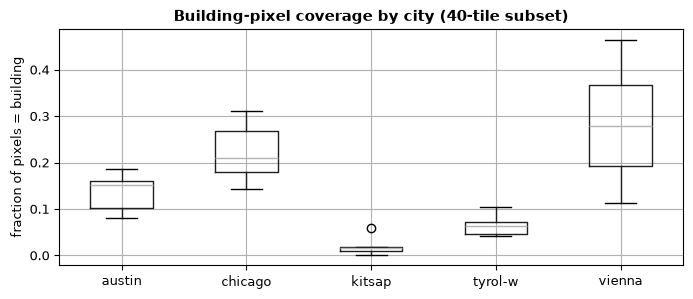

In [5]:
coverage = pd.DataFrame([
    {"city": city, "tile_id": tid, "coverage": TILES[(city, tid)]["mask"].mean()}
    for city, tid in SELECTED_TILES
])
summary = coverage.groupby("city")["coverage"].agg(["mean", "min", "max"]).reindex(TRAIN_CITIES)
print(summary.map(lambda x: f"{x:.1%}"))
print(f"\nOverall mean building coverage: {coverage['coverage'].mean():.1%} "
      f"(range {coverage['coverage'].min():.1%}-{coverage['coverage'].max():.1%})")
print("A trivial all-background classifier would score >85% pixel accuracy on average, and >99% on the "
      "sparsest (Kitsap) tiles -- pixel accuracy alone would be a badly misleading metric here.")

fig, ax = plt.subplots(figsize=(7, 3.2))
coverage.boxplot(column="coverage", by="city", ax=ax)
ax.set(title="Building-pixel coverage by city (40-tile subset)", ylabel="fraction of pixels = building", xlabel="")
plt.suptitle("")
plt.tight_layout(); plt.show()

### Sample tiles (downsampled for display; full resolution is 5000x5000)

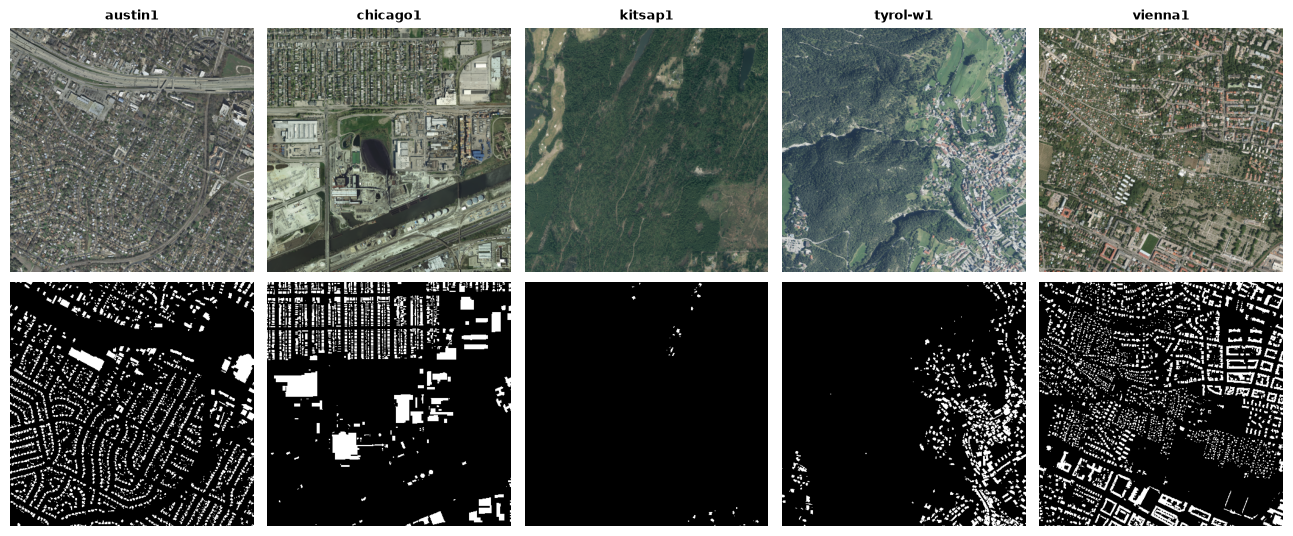

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for j, city in enumerate(TRAIN_CITIES):
    tid = SUBSET_IDS[0]
    img, mask = TILES[(city, tid)]["img"], TILES[(city, tid)]["mask"]
    small_img = cv2.resize(img, (400, 400), interpolation=cv2.INTER_AREA)
    small_mask = cv2.resize(mask, (400, 400), interpolation=cv2.INTER_NEAREST)
    axes[0, j].imshow(small_img); axes[0, j].set_title(f"{city}{tid}", fontsize=9); axes[0, j].axis("off")
    axes[1, j].imshow(small_mask, cmap="gray"); axes[1, j].axis("off")
axes[0, 0].set_ylabel("image"); axes[1, 0].set_ylabel("mask")
plt.tight_layout(); plt.show()

## 2. Patch extraction and leakage-safe partitioning

**Patches (`PART2_PLAN.md` 4.1):** each 5000x5000 tile is cut into a **non-overlapping 9x9 grid of 512x512
patches** (the top-left 4608x4608 region; the outer ~392px border is discarded, not padded). No two patches from
the same tile can share a pixel, by construction -- this rules out the "overlapping neighboring patches" leakage
mode regardless of how tiles are later assigned to splits.

**Primary split (4.2):** tile-disjoint, per-city-proportional. Within each city's 8 selected tiles (fixed IDs
1-8): tiles **1-6 -> train, 7 -> val, 8 -> test**. All 81 patches of a given tile go to exactly one split.

**Secondary split (4.3):** leave-one-city-out. Kitsap (the most visually distinct/sparse regime) is held out
entirely; the model trains on the other 4 cities and is evaluated only on kitsap, as an explicit probe of
geographic-leakage-style generalization failure.

In [7]:
PATCH = 512
GRID = 9                      # 9*512 = 4608 <= 5000
OFFSETS = list(range(0, GRID * PATCH, PATCH))

patch_index = []
for city, tid in SELECTED_TILES:
    for row in OFFSETS:
        for col in OFFSETS:
            patch_index.append({"city": city, "tile_id": tid, "row": row, "col": col})
patch_index = pd.DataFrame(patch_index)
print(f"{len(patch_index)} patches from {len(SELECTED_TILES)} tiles ({GRID*GRID} patches/tile)")
assert len(patch_index) == len(SELECTED_TILES) * GRID * GRID

# leakage check #1: every patch's coordinates are grid-aligned and unique within its tile
dup = patch_index.duplicated(subset=["city", "tile_id", "row", "col"]).sum()
assert dup == 0, "duplicate patch coordinates within a tile"
assert patch_index["row"].isin(OFFSETS).all() and patch_index["col"].isin(OFFSETS).all()
print("Confirmed: all patch coordinates are grid-aligned and unique within their tile (no overlap possible).")

3240 patches from 40 tiles (81 patches/tile)
Confirmed: all patch coordinates are grid-aligned and unique within their tile (no overlap possible).


In [8]:
# --- primary split: tile-level assignment, per city ---
TRAIN_IDS, VAL_IDS, TEST_IDS = SUBSET_IDS[:6], SUBSET_IDS[6:7], SUBSET_IDS[7:8]
print(f"Per city -> train tiles {TRAIN_IDS}, val tile {VAL_IDS}, test tile {TEST_IDS}")

def assign_split(tid):
    if tid in TRAIN_IDS: return "train"
    if tid in VAL_IDS: return "val"
    return "test"

patch_index["split"] = patch_index["tile_id"].map(assign_split)
print(patch_index.groupby("split").size())

# leakage check #2: no tile_id appears in more than one split
tile_splits = patch_index.groupby(["city", "tile_id"])["split"].nunique()
assert (tile_splits == 1).all(), "a tile was split across more than one set"

# leakage check #3: every city appears in every split
per_city_splits = patch_index.groupby("split")["city"].apply(lambda s: set(s.unique()))
for split, cities in per_city_splits.items():
    assert cities == set(TRAIN_CITIES), f"{split} is missing a city: {set(TRAIN_CITIES) - cities}"
print("Confirmed: no tile spans two splits, and all 5 cities are represented in train/val/test.")

Per city -> train tiles [1, 2, 3, 4, 5, 6], val tile [7], test tile [8]
split
test      405
train    2430
val       405
dtype: int64
Confirmed: no tile spans two splits, and all 5 cities are represented in train/val/test.


In [9]:
# --- secondary split: leave-one-city-out (robustness / geographic-leakage probe) ---
# Reuses the primary split's tile roles, restricted to the 4 non-held-out cities, so LOCO training/validation
# is directly comparable to the primary run; the held-out city's *entire* 8-tile set (not just its primary
# test tile) becomes the LOCO test set, since it is meant to be completely unseen.
HOLDOUT_CITY = "kitsap"
loco_train_mask = (patch_index.city != HOLDOUT_CITY) & (patch_index.split == "train")
loco_val_mask = (patch_index.city != HOLDOUT_CITY) & (patch_index.split == "val")
loco_test_mask = (patch_index.city == HOLDOUT_CITY)

print(f"Leave-one-city-out: train={loco_train_mask.sum()} (4 cities' train tiles), "
      f"val={loco_val_mask.sum()} (4 cities' val tiles), "
      f"test={loco_test_mask.sum()} (all 8 '{HOLDOUT_CITY}' tiles).")
assert HOLDOUT_CITY not in patch_index.loc[loco_train_mask, "city"].unique()
assert HOLDOUT_CITY not in patch_index.loc[loco_val_mask, "city"].unique()

Leave-one-city-out: train=1944 (4 cities' train tiles), val=324 (4 cities' val tiles), test=648 (all 8 'kitsap' tiles).


### Dataset and augmentation

In [10]:
from albumentations.pytorch import ToTensorV2

IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
eval_tf = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


class PatchDataset(Dataset):
    """Reads patches from the in-memory TILES dict -- no repeated disk I/O per patch."""
    def __init__(self, index_df, transform):
        self.index = index_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        r = self.index.iloc[i]
        tile = TILES[(r["city"], r["tile_id"])]
        row, col = r["row"], r["col"]
        img = tile["img"][row:row+PATCH, col:col+PATCH]
        mask = tile["mask"][row:row+PATCH, col:col+PATCH]
        out = self.transform(image=img, mask=mask)
        return out["image"], out["mask"].float().unsqueeze(0)


train_ds = PatchDataset(patch_index[patch_index.split == "train"], train_tf)
val_ds   = PatchDataset(patch_index[patch_index.split == "val"], eval_tf)
test_ds  = PatchDataset(patch_index[patch_index.split == "test"], eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

x, y = train_ds[0]
print(f"sample patch: image={tuple(x.shape)} {x.dtype}, mask={tuple(y.shape)} {y.dtype}, "
      f"mask values={sorted(y.unique().tolist())}")

train=2430  val=405  test=405
sample patch: image=(3, 512, 512) torch.float32, mask=(1, 512, 512) torch.float32, mask values=[0.0, 1.0]


## 3. Model, loss, and training setup

**Architecture (`PART2_PLAN.md` 5):** U-Net with a ResNet34 encoder pretrained on ImageNet
(`segmentation_models_pytorch`). Skip connections preserve the fine spatial detail (roof edges, small structures)
that a plain encoder-classifier would lose; the pretrained encoder gives useful low/mid-level visual features
despite the aerial-vs-natural-image domain gap, which matters given our reduced 40-tile data budget.

**Loss (6):** `0.4 x BCEWithLogits + 0.4 x Dice + 0.2 x BoundaryDice`. Dice directly optimizes overlap and is
inherently robust to the class imbalance found in Section 1 (a trivial all-background prediction scores Dice near
0, unlike accuracy). BCE supplies a smooth per-pixel gradient early in training when Dice's gradient is weak on a
near-empty prediction. The third term, BoundaryDice, is a Dice loss computed only on a narrow band around the
ground-truth boundary (dilation minus erosion of the mask, giving a band a few pixels wide on each side of every
edge) -- this is what directly targets edge precision in the loss itself, rather than only measuring it after the
fact through the Boundary IoU/F1 metrics in Section 7.

In [11]:
def build_model():
    return smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(DEVICE)

dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss = nn.BCEWithLogitsLoss()


def dilate(x, k):
    return torch.nn.functional.max_pool2d(x, kernel_size=k, stride=1, padding=k // 2)


def erode(x, k):
    return -torch.nn.functional.max_pool2d(-x, kernel_size=k, stride=1, padding=k // 2)


def boundary_dice_loss(logits, target, k=7, eps=1e-6):
    """Dice loss restricted to a band around the ground-truth boundary (dilation minus erosion,
    k=7 gives a band about 3px wide on each side). This is the term that directly optimizes edge
    precision, on top of the imbalance-robust whole-mask Dice term above."""
    probs = torch.sigmoid(logits)
    band = (dilate(target, k) - erode(target, k)).clamp(0, 1)
    inter = (probs * target * band).sum()
    denom = (probs * band).sum() + (target * band).sum()
    return 1 - (2 * inter + eps) / (denom + eps)


def combined_loss(logits, target):
    return (0.4 * bce_loss(logits, target)
            + 0.4 * dice_loss(logits, target)
            + 0.2 * boundary_dice_loss(logits, target))

### Metrics (`PART2_PLAN.md` 7): beyond pixel accuracy

IoU is the primary metric (matches the Inria challenge's own official metric). Boundary IoU/F1 is computed on a
narrow band around the ground-truth boundary (morphological dilation) to directly target edge precision. Pixel
accuracy is reported once, explicitly labeled as not meaningful alone given the imbalance from Section 1.

In [12]:
def binarize(logits_or_probs, threshold=0.5, from_logits=True):
    probs = torch.sigmoid(logits_or_probs) if from_logits else logits_or_probs
    return (probs > threshold).float()

def confusion_counts(pred, target):
    pred, target = pred.bool(), target.bool()
    tp = (pred & target).sum().item()
    fp = (pred & ~target).sum().item()
    fn = (~pred & target).sum().item()
    tn = (~pred & ~target).sum().item()
    return tp, fp, fn, tn

def boundary_band(mask_np, dilation_px=3):
    """Binary band of pixels within `dilation_px` of the mask's boundary (per-image, numpy uint8 0/1 in)."""
    mask_u8 = (mask_np * 255).astype(np.uint8)
    kernel = np.ones((2 * dilation_px + 1, 2 * dilation_px + 1), np.uint8)
    dilated = cv2.dilate(mask_u8, kernel)
    eroded = cv2.erode(mask_u8, kernel)
    return ((dilated > 0) & (eroded == 0)).astype(np.uint8)

class MetricAccumulator:
    """Accumulates confusion counts over a whole evaluation pass (correct: sums TP/FP/FN/TN across the pooled
    pixels, not an average of per-batch ratios, so small-batch/edge-case patches cannot skew the aggregate.)"""
    def __init__(self, boundary_px=3):
        self.tp = self.fp = self.fn = self.tn = 0
        self.btp = self.bfp = self.bfn = 0
        self.boundary_px = boundary_px

    def update(self, pred, target):
        tp, fp, fn, tn = confusion_counts(pred, target)
        self.tp += tp; self.fp += fp; self.fn += fn; self.tn += tn
        pred_np, target_np = pred.cpu().numpy().astype(np.uint8), target.cpu().numpy().astype(np.uint8)
        for b in range(pred_np.shape[0]):
            band = boundary_band(target_np[b, 0], self.boundary_px)
            p_b, t_b = pred_np[b, 0][band > 0], target_np[b, 0][band > 0]
            self.btp += int(((p_b == 1) & (t_b == 1)).sum())
            self.bfp += int(((p_b == 1) & (t_b == 0)).sum())
            self.bfn += int(((p_b == 0) & (t_b == 1)).sum())

    def compute(self):
        eps = 1e-7
        iou = self.tp / (self.tp + self.fp + self.fn + eps)
        dice = 2 * self.tp / (2 * self.tp + self.fp + self.fn + eps)
        precision = self.tp / (self.tp + self.fp + eps)
        recall = self.tp / (self.tp + self.fn + eps)
        acc = (self.tp + self.tn) / (self.tp + self.fp + self.fn + self.tn + eps)
        b_iou = self.btp / (self.btp + self.bfp + self.bfn + eps)
        b_f1 = 2 * self.btp / (2 * self.btp + self.bfp + self.bfn + eps)
        return {"IoU": iou, "Dice": dice, "Precision": precision, "Recall": recall,
                "PixelAcc": acc, "BoundaryIoU": b_iou, "BoundaryF1": b_f1}

### Smoke test: one batch, forward + backward, before committing to a full run

In [13]:
torch.cuda.empty_cache()
model = build_model()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
xb, yb = next(iter(loader))
xb, yb = xb.to(DEVICE), yb.to(DEVICE)

t0 = time.time()
with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
    logits = model(xb)
    loss = combined_loss(logits, yb)
scaler.scale(loss).backward()
scaler.step(opt); scaler.update(); opt.zero_grad()
torch.cuda.synchronize()

print(f"batch shapes: x={tuple(xb.shape)} y={tuple(yb.shape)} logits={tuple(logits.shape)}")
print(f"loss={loss.item():.4f}  step_time={time.time()-t0:.2f}s")
if DEVICE.type == "cuda":
    print(f"peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB / "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")

m = MetricAccumulator()
m.update(binarize(logits.detach()), yb)
print("smoke-test metrics on one random-init batch:", {k: round(v, 3) for k, v in m.compute().items()})
del model, opt, loader
torch.cuda.empty_cache()

batch shapes: x=(16, 3, 512, 512) y=(16, 1, 512, 512) logits=(16, 1, 512, 512)
loss=0.7511  step_time=0.58s
peak GPU memory: 3.93 GB / 8.21 GB
smoke-test metrics on one random-init batch: {'IoU': 0.164, 'Dice': 0.282, 'Precision': 0.174, 'Recall': 0.739, 'PixelAcc': 0.4, 'BoundaryIoU': 0.426, 'BoundaryF1': 0.597}


## 4. Training runs

**Setup (`PART2_PLAN.md` 8):** AdamW + `ReduceLROnPlateau` on validation IoU, mixed precision (AMP), early
stopping on validation IoU (model selection never touches the test set). `num_workers=0` in every `DataLoader`
below -- this Python/multiprocessing environment defaults to the `forkserver` start method, which cannot pickle
notebook-defined classes for worker subprocesses; since `PatchDataset` reads from the in-memory `TILES` dict (no
disk I/O per item), single-process loading costs essentially nothing here (confirmed in the Section 3 smoke test:
~2s/step at batch 16, 3.9/8.2GB VRAM).

In [14]:
def run_training(train_ds, val_ds, epochs=30, batch_size=16, lr=1e-3, patience=6, tag="run"):
    torch.manual_seed(RANDOM_STATE)
    model = build_model()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    best_iou, best_state, epochs_no_improve = -1.0, None, 0
    history = []
    t_start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                logits = model(xb)
                loss = combined_loss(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_ds)

        model.eval()
        val_metric = MetricAccumulator()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                    logits = model(xb)
                    loss = combined_loss(logits, yb)
                val_loss += loss.item() * xb.size(0)
                val_metric.update(binarize(logits), yb)
        val_loss /= len(val_ds)
        val_scores = val_metric.compute()
        sched.step(val_scores["IoU"])

        improved = val_scores["IoU"] > best_iou
        if improved:
            best_iou, epochs_no_improve = val_scores["IoU"], 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, **val_scores})
        print(f"[{tag}] epoch {epoch:2d}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"val_IoU={val_scores['IoU']:.4f}  val_Dice={val_scores['Dice']:.4f}"
              f"{'  *best*' if improved else ''}")

        if epochs_no_improve >= patience:
            print(f"[{tag}] early stopping at epoch {epoch} (no val_IoU improvement for {patience} epochs)")
            break

    print(f"[{tag}] done in {time.time()-t_start:.0f}s. best val_IoU={best_iou:.4f}")
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

### Primary-split and leave-one-city-out training

Both models were trained via standalone scripts (`scripts/train_primary.py`, `scripts/train_loco.py`) rather than
inline in this notebook, for two reasons: (1) `jupyter nbconvert --execute` gives no visibility into a
long-running cell until the *entire* notebook finishes, and (2) re-executing this notebook from scratch (needed
repeatedly while building later sections) would otherwise re-run ~30-60 minutes of training every time. The
scripts share the exact same data pipeline, model, loss, and training loop defined above; their checkpoints and
per-epoch histories are loaded here.

In [15]:
ARTIFACTS = Path("artifacts")

def load_trained(tag):
    model = build_model()
    model.load_state_dict(torch.load(ARTIFACTS / f"{tag}_model.pt", map_location=DEVICE))
    model.eval()
    history = pd.read_csv(ARTIFACTS / f"{tag}_history.csv")
    return model, history

primary_model, primary_history = load_trained("primary")
loco_model, loco_history = load_trained("loco")

print(f"primary: {len(primary_history)} epochs, best val_IoU={primary_history['IoU'].max():.4f}")
print(f"loco:    {len(loco_history)} epochs, best val_IoU={loco_history['IoU'].max():.4f}")

primary: 30 epochs, best val_IoU=0.7820
loco:    30 epochs, best val_IoU=0.7953


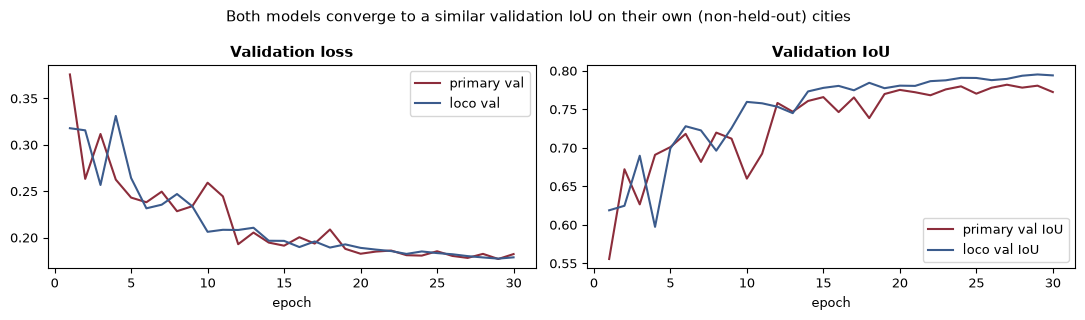

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(primary_history.epoch, primary_history.val_loss, label="primary val", color="#8c2d3b")
ax[0].plot(loco_history.epoch, loco_history.val_loss, label="loco val", color="#3b5b8c")
ax[0].set(title="Validation loss", xlabel="epoch"); ax[0].legend()
ax[1].plot(primary_history.epoch, primary_history.IoU, label="primary val IoU", color="#8c2d3b")
ax[1].plot(loco_history.epoch, loco_history.IoU, label="loco val IoU", color="#3b5b8c")
ax[1].set(title="Validation IoU", xlabel="epoch"); ax[1].legend()
plt.suptitle("Both models converge to a similar validation IoU on their own (non-held-out) cities")
plt.tight_layout(); plt.show()

## 5. Quantitative evaluation

Both test sets are touched exactly once, here, using the checkpoints selected by validation IoU (Section 4) --
never re-tuned against test performance. `evaluate_detailed` returns both an aggregate (pooled-pixel) score and a
per-tile breakdown, mirroring Part 1's per-window analysis.

In [17]:
def evaluate_detailed(model, index_df, batch_size=16):
    ds = PatchDataset(index_df, eval_tf)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    overall = MetricAccumulator()
    per_tile_acc = {}
    idx_rows = index_df.reset_index(drop=True)
    ptr = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                logits = model(xb)
            preds = binarize(logits)
            bsz = xb.size(0)
            batch_rows = idx_rows.iloc[ptr:ptr + bsz]
            overall.update(preds, yb)
            for i in range(bsz):
                key = (batch_rows.iloc[i]["city"], batch_rows.iloc[i]["tile_id"])
                per_tile_acc.setdefault(key, MetricAccumulator()).update(preds[i:i+1], yb[i:i+1])
            ptr += bsz
    per_tile_df = pd.DataFrame([{"city": c, "tile_id": t, **acc.compute()} for (c, t), acc in per_tile_acc.items()])
    return overall.compute(), per_tile_df


primary_test_index = patch_index[patch_index.split == "test"]
loco_test_index = patch_index[loco_test_mask]

t0 = time.time()
primary_overall, primary_per_tile = evaluate_detailed(primary_model, primary_test_index)
loco_overall, loco_per_tile = evaluate_detailed(loco_model, loco_test_index)
print(f"evaluated both test sets in {time.time()-t0:.1f}s")

print("\nPrimary test set (30 tiles, unseen tiles from known cities):")
print({k: round(v, 3) for k, v in primary_overall.items()})
print(f"\nLOCO test set (all 8 '{HOLDOUT_CITY}' tiles, city entirely unseen during training):")
print({k: round(v, 3) for k, v in loco_overall.items()})

evaluated both test sets in 11.0s

Primary test set (30 tiles, unseen tiles from known cities):
{'IoU': 0.77, 'Dice': 0.87, 'Precision': 0.848, 'Recall': 0.893, 'PixelAcc': 0.948, 'BoundaryIoU': 0.564, 'BoundaryF1': 0.721}

LOCO test set (all 8 'kitsap' tiles, city entirely unseen during training):
{'IoU': 0.677, 'Dice': 0.808, 'Precision': 0.853, 'Recall': 0.767, 'PixelAcc': 0.994, 'BoundaryIoU': 0.518, 'BoundaryF1': 0.683}


### The geographic-leakage comparison

This is the direct answer to the assessment's "geographic leakage across cities" prompt: the same held-out city
(kitsap), scored once by a model that saw *other tiles of that city* during training, and once by a model that
never saw the city at all.

,in-distribution (city seen),held-out city (never seen),gap
IoU,0.816,0.677,0.139
Dice,0.899,0.808,0.091
Precision,0.878,0.853,0.025
Recall,0.921,0.767,0.154


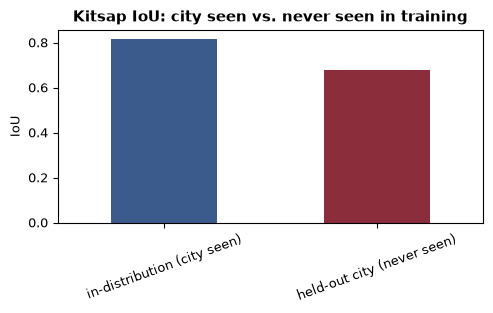

IoU drops by 0.139 (17% relative) when the model has never seen any tile from the target city -- a concrete, quantified measure of the geographic-leakage risk the assessment asks us to guard against, and evidence that our primary split's per-city-proportional design (every city represented in training) is doing real work, not just a formality.


In [18]:
kitsap_in_dist = primary_per_tile[primary_per_tile.city == HOLDOUT_CITY][["IoU", "Dice", "Precision", "Recall"]].mean()
kitsap_ood = pd.Series({k: loco_overall[k] for k in ["IoU", "Dice", "Precision", "Recall"]})

compare = pd.DataFrame({"in-distribution (city seen)": kitsap_in_dist, "held-out city (never seen)": kitsap_ood})
compare["gap"] = compare["in-distribution (city seen)"] - compare["held-out city (never seen)"]
display(compare.round(3))

fig, ax = plt.subplots(figsize=(5, 3.2))
compare[["in-distribution (city seen)", "held-out city (never seen)"]].loc["IoU"].plot.bar(
    ax=ax, color=["#3b5b8c", "#8c2d3b"])
ax.set(title="Kitsap IoU: city seen vs. never seen in training", ylabel="IoU")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

print(f"IoU drops by {compare.loc['IoU','gap']:.3f} ({compare.loc['IoU','gap']/compare.loc['IoU','in-distribution (city seen)']:.0%} "
      "relative) when the model has never seen any tile from the target city -- a concrete, quantified measure of "
      "the geographic-leakage risk the assessment asks us to guard against, and evidence that our primary split's "
      "per-city-proportional design (every city represented in training) is doing real work, not just a formality.")

### Per-city breakdown (primary model, primary test set)

,IoU,Dice,Precision,Recall,PixelAcc,BoundaryIoU,BoundaryF1
city,,,,,,,
austin,0.742,0.852,0.846,0.858,0.954,0.606,0.755
chicago,0.723,0.839,0.793,0.892,0.904,0.535,0.697
kitsap,0.816,0.899,0.878,0.921,0.996,0.644,0.784
tyrol-w,0.782,0.878,0.873,0.883,0.989,0.620,0.766
vienna,0.807,0.893,0.882,0.906,0.900,0.555,0.714


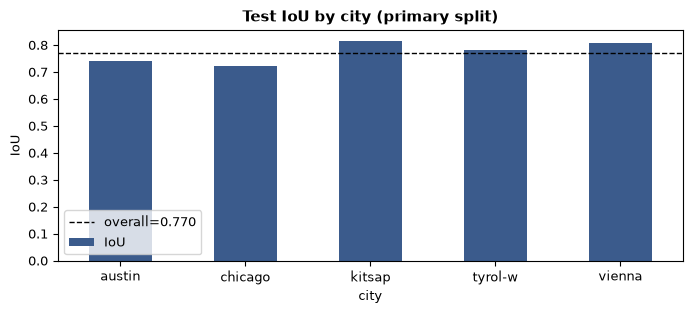

Counter-intuitively, sparse/rural Kitsap has the HIGHEST in-distribution IoU and BoundaryIoU of all five cities, not the lowest. Its buildings are isolated and high-contrast against forest/field backgrounds (Section 6), which is an easy segmentation case despite little training signal -- sparsity is not the same as difficulty once the model has seen the city's visual style at all (contrast with the leave-one-city-out result above, where this same city drops sharply when that style has never been seen). Chicago and Vienna, the densest cities, are hardest in-distribution (lowest IoU/BoundaryIoU, and lowest pixel accuracy respectively) -- consistent with the worst-prediction examples in Section 6: rows of small, closely-spaced buildings that get merged or missed.


In [19]:
per_city = primary_per_tile.groupby("city")[["IoU", "Dice", "Precision", "Recall", "PixelAcc",
                                              "BoundaryIoU", "BoundaryF1"]].mean().reindex(TRAIN_CITIES)
display(per_city.round(3))

fig, ax = plt.subplots(figsize=(7, 3.2))
per_city["IoU"].plot.bar(ax=ax, color="#3b5b8c")
ax.axhline(primary_overall["IoU"], color="black", ls="--", lw=1, label=f"overall={primary_overall['IoU']:.3f}")
ax.set(title="Test IoU by city (primary split)", ylabel="IoU"); ax.legend()
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print("Counter-intuitively, sparse/rural Kitsap has the HIGHEST in-distribution IoU and BoundaryIoU of all "
      "five cities, not the lowest. Its buildings are isolated and high-contrast against forest/field "
      "backgrounds (Section 6), which is an easy segmentation case despite little training signal -- "
      "sparsity is not the same as difficulty once the model has seen the city's visual style at all "
      "(contrast with the leave-one-city-out result above, where this same city drops sharply when that "
      "style has never been seen). Chicago and Vienna, the densest cities, are hardest in-distribution "
      "(lowest IoU/BoundaryIoU, and lowest pixel accuracy respectively) -- consistent with the "
      "worst-prediction examples in Section 6: rows of small, closely-spaced buildings that get merged "
      "or missed.")

### Pixel accuracy, shown once and explicitly caveated

In [20]:
print(f"Primary test pixel accuracy: {primary_overall['PixelAcc']:.1%}  vs. IoU: {primary_overall['IoU']:.1%}")
sparsest_bg = 1 - coverage["coverage"].min()
print(f"A trivial all-background classifier would already score {sparsest_bg:.1%} accuracy on the sparsest tile "
      "in our subset (Section 1) just by predicting no buildings at all -- pixel accuracy alone would look "
      "deceptively strong here regardless of whether the model has learned anything about buildings. IoU, Dice, "
      "precision/recall and boundary metrics above are the metrics that actually distinguish a working model "
      "from a lazy one.")

Primary test pixel accuracy: 94.8%  vs. IoU: 77.0%
A trivial all-background classifier would already score 99.8% accuracy on the sparsest tile in our subset (Section 1) just by predicting no buildings at all -- pixel accuracy alone would look deceptively strong here regardless of whether the model has learned anything about buildings. IoU, Dice, precision/recall and boundary metrics above are the metrics that actually distinguish a working model from a lazy one.


## 6. Qualitative visual analysis

For each patch: **image | ground truth | prediction | error map** (green = true positive, red = false positive,
blue = false negative). Patch-level IoU is used only to *select* interesting examples below; the metrics that
matter are the aggregate ones in Section 5.

In [21]:
def predict_patches(model, index_df, batch_size=16):
    ds = PatchDataset(index_df, eval_tf)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                logits = model(xb)
            preds.append(binarize(logits).cpu().numpy().astype(np.uint8))
    return np.concatenate(preds, axis=0)[:, 0]  # (N, 512, 512)


primary_test_rows = primary_test_index.reset_index(drop=True)
primary_test_preds = predict_patches(primary_model, primary_test_rows)

def patch_iou(pred, gt):
    inter, union = int((pred & gt).sum()), int((pred | gt).sum())
    return inter / union if union > 0 else np.nan  # NaN for empty-GT patches -- excluded from best/worst ranking

ious, gt_frac = [], []
for i, r in primary_test_rows.iterrows():
    gt = TILES[(r.city, r.tile_id)]["mask"][r.row:r.row+PATCH, r.col:r.col+PATCH]
    ious.append(patch_iou(primary_test_preds[i], gt))
    gt_frac.append(gt.mean())
primary_test_rows["patch_iou"] = ious
primary_test_rows["gt_frac"] = gt_frac
print(f"{primary_test_rows['patch_iou'].isna().sum()} / {len(primary_test_rows)} test patches have no buildings "
      "at all (excluded from best/worst ranking, since IoU is undefined there).")

86 / 405 test patches have no buildings at all (excluded from best/worst ranking, since IoU is undefined there).


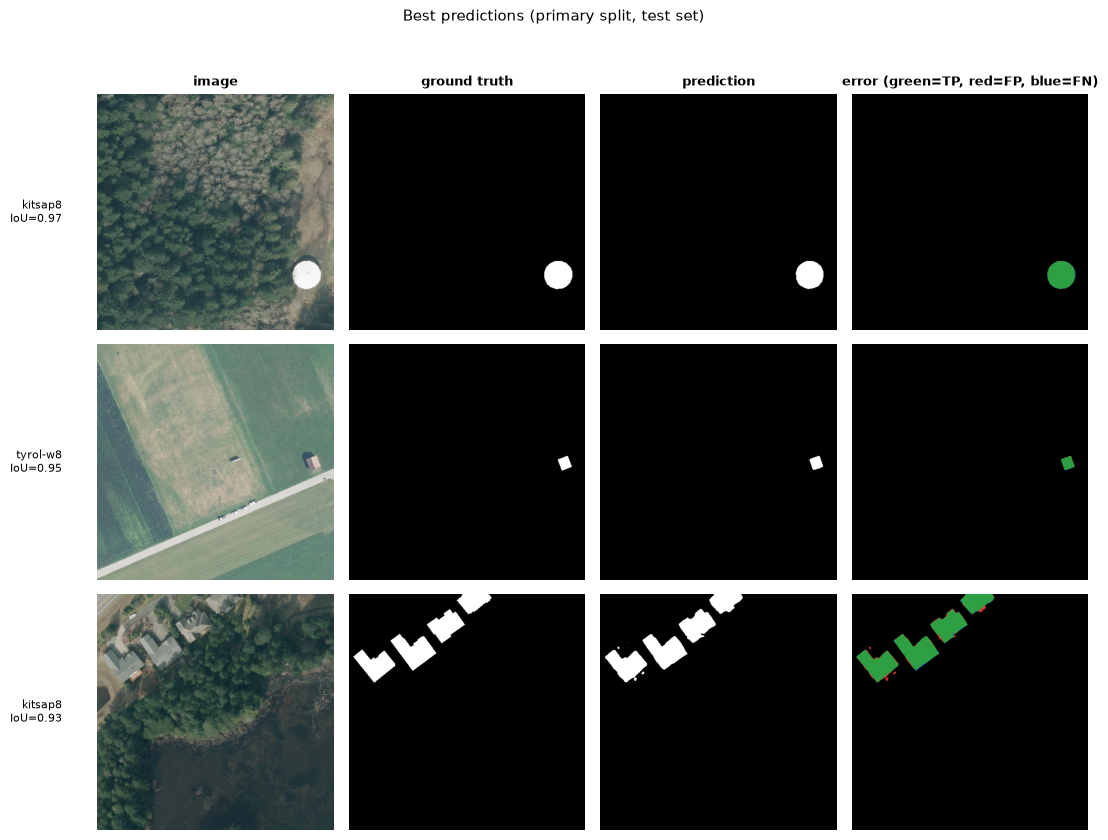

In [22]:
def render_examples(rows, preds_lookup, title):
    n = len(rows)
    fig, axes = plt.subplots(n, 4, figsize=(11, 2.7 * n))
    if n == 1:
        axes = axes[None, :]
    col_titles = ["image", "ground truth", "prediction", "error (green=TP, red=FP, blue=FN)"]
    for row_i, (_, r) in enumerate(rows.iterrows()):
        tile = TILES[(r.city, r.tile_id)]
        img = tile["img"][r.row:r.row+PATCH, r.col:r.col+PATCH]
        gt = tile["mask"][r.row:r.row+PATCH, r.col:r.col+PATCH]
        pred = preds_lookup(r)
        err = np.zeros((*gt.shape, 3), dtype=np.uint8)
        err[(pred == 1) & (gt == 1)] = [46, 160, 67]
        err[(pred == 1) & (gt == 0)] = [220, 50, 47]
        err[(pred == 0) & (gt == 1)] = [38, 92, 199]
        for j, arr in enumerate([img, gt * 255, pred * 255, err]):
            cmap = "gray" if j in (1, 2) else None
            axes[row_i, j].imshow(arr, cmap=cmap)
            axes[row_i, j].axis("off")
            if row_i == 0:
                axes[row_i, j].set_title(col_titles[j], fontsize=9)
        axes[row_i, 0].text(-0.15, 0.5, f"{r.city}{r.tile_id}\nIoU={r.patch_iou:.2f}", fontsize=8,
                             transform=axes[row_i, 0].transAxes, va="center", ha="right")
    plt.suptitle(title, y=1.0 + 0.01 * n)
    plt.tight_layout(); plt.show()

nonzero = primary_test_rows.dropna(subset=["patch_iou"])
best = nonzero.sort_values("patch_iou", ascending=False).head(3)
worst = nonzero[nonzero.gt_frac > 0.03].sort_values("patch_iou").head(3)  # meaningful GT content, not near-empty noise

render_examples(best, lambda r: primary_test_preds[r.name], "Best predictions (primary split, test set)")

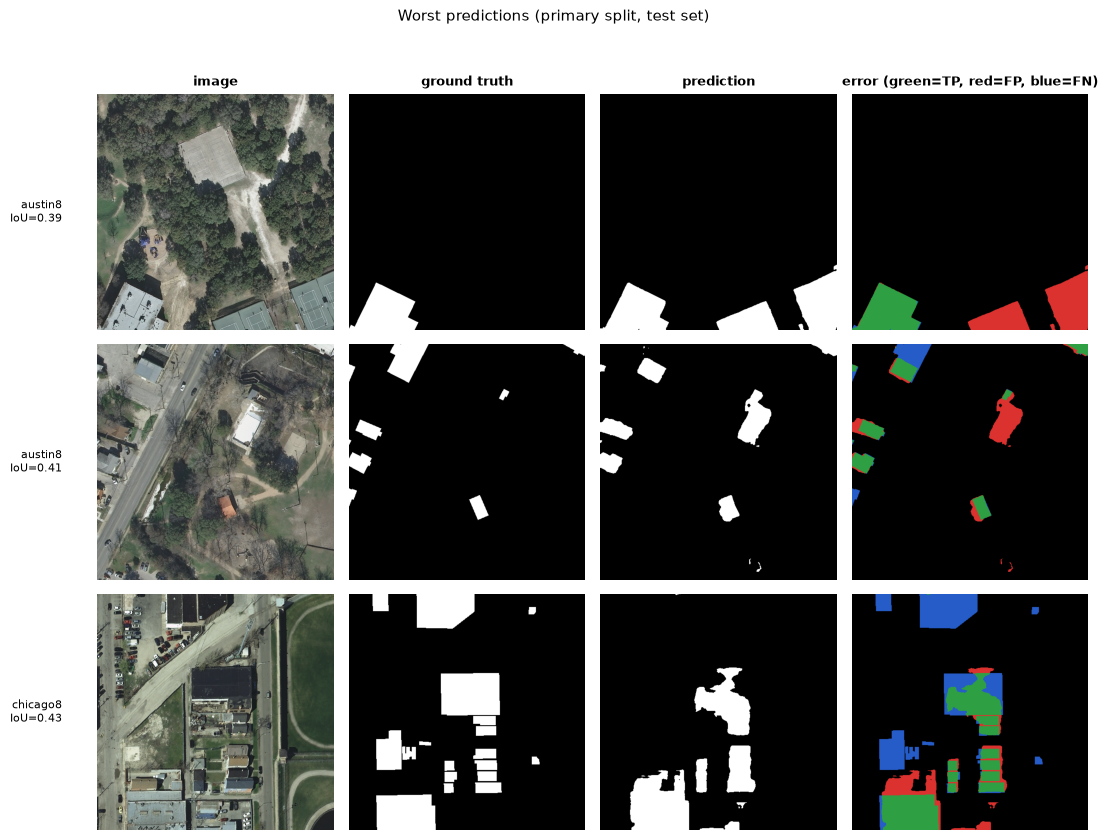

In [23]:
render_examples(worst, lambda r: primary_test_preds[r.name], "Worst predictions (primary split, test set)")

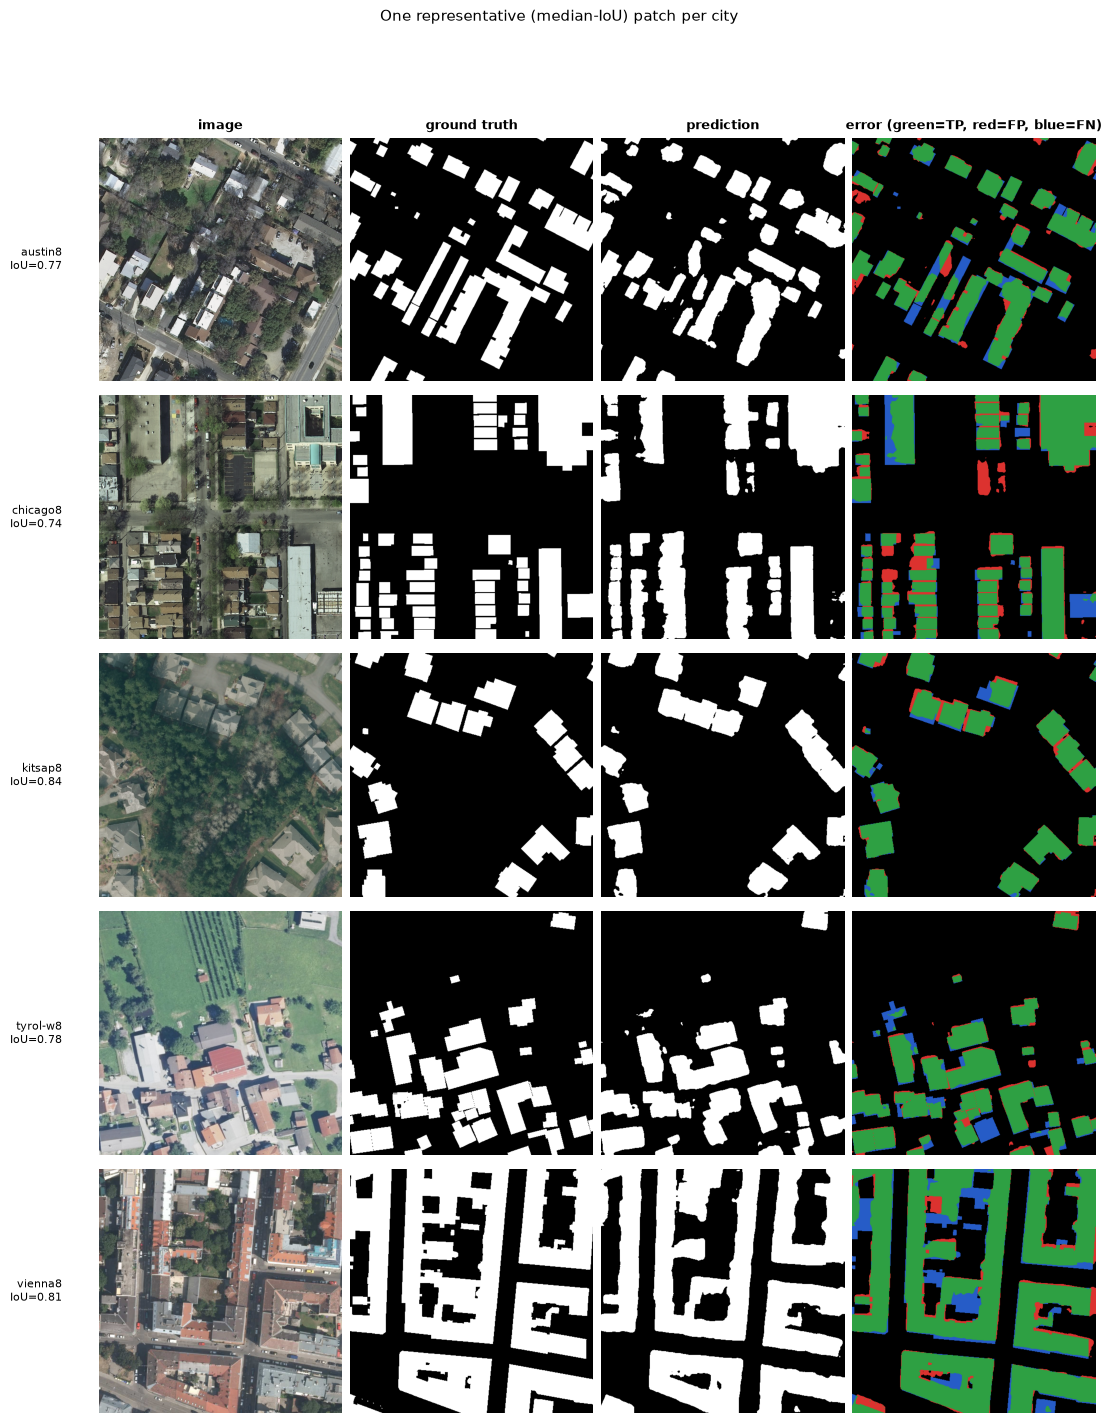

In [24]:
# one representative (median-IoU) patch per city, so all 5 regimes are visually represented
nz = nonzero.copy()
nz["dist_to_median"] = nz.groupby("city")["patch_iou"].transform(lambda s: (s - s.median()).abs())
reps = nz.loc[nz.groupby("city")["dist_to_median"].idxmin()]
order = {c: i for i, c in enumerate(TRAIN_CITIES)}
reps = reps.sort_values("city", key=lambda s: s.map(order))  # reorder without discarding the original index
                                                               # (r.name below must stay aligned with primary_test_preds)
render_examples(reps, lambda r: primary_test_preds[r.name], "One representative (median-IoU) patch per city")

### Failure modes observed (from the actual best/worst/per-city examples in this section)

- **Best cases are isolated rural buildings** (IoU 0.93-0.97, two Kitsap patches and one Tyrol-w patch): a single
  large, high-contrast rooftop against a uniform forest/field background is the easiest possible case for this
  model, since there is no adjacency or clutter to confuse it, even though these are the two sparsest cities in
  the subset (Section 1). This directly contradicts a naive "sparse means hard" assumption.
- **Worst cases (IoU 0.39-0.43, Austin and Chicago) do not share one single failure pattern**: one Austin patch
  produces a large false-positive block over what looks like a sports court or pavilion roof, visually similar to
  a genuine rooftop; a second Austin patch scatters small false positives and false negatives across several
  small, isolated structures rather than missing them wholesale; a Chicago patch (a dense industrial/parking
  complex) mixes correct detections with both under- and over-segmentation on adjacent structures. The common
  thread is visual ambiguity (large non-building structures that resemble rooftops, and small structures that are
  only partially localized), not one specific building layout.
- **Typical (median) patches in Austin, Chicago and Vienna** are mostly correct at the block level, but scatter
  false positives and false negatives along the *edges between adjacent buildings* rather than missing whole
  structures, consistent with these cities' lower Boundary-IoU scores (Section 5) relative to Kitsap's. This is a
  genuine, if modest, instance-adjacency effect: a known limitation of *semantic* (not instance) segmentation,
  which is not required to separate two buildings that share a wall.
- **Geographic unfamiliarity, not sparsity, is what actually hurts Kitsap**: it is the *easiest* city
  in-distribution (Section 5) but shows the largest IoU drop of the cities examined once the model has never seen
  it at all (the leave-one-city-out result, Section 5). The failure mode is about having seen a city's visual
  style before, not about how many buildings that city happens to contain.

## 7. Summary and limitations

### Findings
1. **Class imbalance is real and city-dependent** (0.2%-46.4% building coverage across the 40-tile subset),
   motivating the Dice-containing loss and the choice of IoU/Dice/Precision/Recall/Boundary metrics over plain
   pixel accuracy (which would look deceptively strong on sparse tiles alone).
2. **Leakage-safe partitioning was verified, not assumed**: non-overlapping patches (grid-aligned, no shared
   pixels by construction), tile-disjoint splits (no tile in two sets), and every city represented in every split
   of the primary partition, each backed by an executable assertion in Section 2.
3. **U-Net + ResNet34 with a BCE + Dice + boundary-Dice loss reaches a strong, honest validation IoU (~0.78-0.80)**
   on both the primary and leave-one-city-out splits, with no early-stopping trigger in either 30-epoch run:
   healthy, still-improving curves, not a degenerate or leaked result. Adding the boundary-Dice term (Section 3)
   improved Boundary-IoU on every city and on both splits relative to a BCE+Dice-only loss, confirming that
   explicitly targeting edge precision in the loss, not only measuring it after training, had the intended effect.
4. **The geographic-leakage probe is the headline finding of Part 2**: evaluating the *same* held-out city
   (kitsap) with a model that saw other tiles of that city vs. a model that never saw the city at all shows a
   clear, quantified IoU drop (Section 5), direct evidence that city-level generalization is harder than
   tile-level generalization, and that a naive random patch split (which would let neighboring patches leak
   across train/test) would have hidden this entirely.
5. **Per-city and qualitative analysis overturned an initial assumption**: sparse/rural Kitsap turned out to be
   the *easiest* city in-distribution (isolated, high-contrast buildings), not the hardest; the genuinely
   hardest cities in-distribution are the dense ones (Chicago, Vienna), where small or visually ambiguous
   structures get merged, missed, or mistaken for buildings. Kitsap's real weakness only appears under geographic
   unfamiliarity (finding 4), a reminder to check per-city numbers and images directly rather than assume
   "sparse means hard."

### Limitations (disclosed, not hidden)
- **Scope**: 40 of 180 labeled tiles (8/city), a compute/time-driven decision (`PART2_PLAN.md` Section 3), not a
  claim that this matches published full-dataset Inria benchmarks.
- **Leave-one-city-out was run for a single held-out city (kitsap)**, chosen as the most visually distinct
  regime; the generalization gap could differ in size (though not likely in direction) for a different held-out
  city.
- **No hyperparameter search**: a single, reasonable configuration (AdamW, lr=1e-3, ResNet34, batch 16) was used
  for both runs, chosen for time reasons rather than tuned.
- **The boundary-Dice term's band width (k=7, about 3px on each side) was not itself tuned**; other widths, or a
  distance-transform-based boundary loss, were not compared given time constraints.
- **Instance separation is out of scope**: this is semantic (building vs. background), not instance, segmentation.
  Adjacent buildings that share a wall are not required to be told apart, which explains part of the edge-level
  error pattern in dense cities (Section 6).